# Exploratory data analysis

## Research question

Among respondents aged 16 and over in the EU Loneliness Survey 2022,
is more frequent face-to-face contact with friends more strongly
associated with lower loneliness than more frequent remote contact?

## Approach

We describe the prepared sample, compare loneliness across contact
frequencies and calculate exploratory rank correlations. We also
examine relevant contextual variables to understand the wider pattern.

The analysis uses the data prepared in Notebook 1 and builds on the
exploratory methods covered in Week 3. All results are unweighted
and describe the analysed respondents.

Source: [EU Loneliness Survey](https://doi.org/10.2905/JRC.V4VT8T8).

## 1 Import libraries and set paths

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "eu_loneliness_analysis_sample.csv"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Cannot find {DATA_PATH}. Run the data inspection and cleaning notebook first.")

sns.set_theme(style="whitegrid", context="notebook")
print("Prepared data:", DATA_PATH)

Prepared data: c:\Users\35383\OneDrive\Documents\GitHub\ProjectCSC1169\data\processed\eu_loneliness_analysis_sample.csv


## 2 Load and check the prepared data

We check that the imported sample has unique respondent IDs, valid
ages, complete core responses and correctly calculated UCLA scores.

In [2]:
df = pd.read_csv(DATA_PATH)
contact_cols = ["friends_meet_face", "friends_meet_tele"]
ucla_cols = ["loneliness_ucla_a", "loneliness_ucla_b", "loneliness_ucla_c"]
required_cols = ["id_pers", "country", "age", "ucla_total"] + contact_cols + ucla_cols

assert set(required_cols).issubset(df.columns)
assert df["id_pers"].is_unique
assert not df[required_cols].isna().any().any()
assert df["age"].ge(16).all()
assert df[contact_cols].isin(range(1, 8)).all().all()
assert df[ucla_cols].isin([1, 2, 3]).all().all()
assert df["ucla_total"].between(3, 9).all()
assert df["ucla_total"].eq(df[ucla_cols].sum(axis=1)).all()

print(f"Analysis sample: {len(df):,} respondents")
print(f"Countries represented: {df['country'].nunique()}")
print("All checks passed.")
display(df[required_cols].head())

Analysis sample: 24,431 respondents
Countries represented: 27
All checks passed.


,id_pers,country,age,ucla_total,friends_meet_face,friends_meet_tele,loneliness_ucla_a,loneliness_ucla_b,loneliness_ucla_c
0,1,1,32.0,5.0,6.0,6.0,1.0,2.0,2.0
1,2,1,56.0,4.0,3.0,4.0,2.0,1.0,1.0
2,3,1,45.0,3.0,3.0,3.0,1.0,1.0,1.0
3,4,1,35.0,4.0,5.0,7.0,1.0,2.0,1.0
4,5,1,43.0,5.0,5.0,6.0,3.0,1.0,1.0


## 3 Define contact labels

We use the questionnaire labels to display contact frequencies.
The codes represent ordered categories rather than exact numbers
of contacts.

In [4]:
contact_labels = {
    1: "Never",
    2: "Every two months\nor less frequently",
    3: "Once a month",
    4: "Every two weeks",
    5: "Every week",
    6: "More than once\na week",
    7: "Daily",
}
contact_names = {
    "friends_meet_face": "Face-to-face contact",
    "friends_meet_tele": "Remote contact",
}
contact_order = list(contact_labels.keys())
contact_colours = {
    "friends_meet_face": "#2878A5",
    "friends_meet_tele": "#C46B2B",
}

## 4 Summarise age and loneliness

We calculate the centre, spread and range of age and loneliness
scores to describe the main analysis sample.

In [5]:
descriptive_stats = df[["age", "ucla_total"]].describe().T

descriptive_stats["IQR"] = descriptive_stats["75%"] - descriptive_stats["25%"]
descriptive_stats = descriptive_stats.rename(
    index={"age": "Age", "ucla_total": "UCLA loneliness total"},
    columns={"count": "n", "mean": "Mean", "std": "SD", "min": "Minimum",
             "25%": "Q1", "50%": "Median", "75%": "Q3", "max": "Maximum"},
)
display(descriptive_stats.round(2))
descriptive_stats.round(2).to_csv(TABLES_DIR / "descriptive_statistics.csv")

,n,Mean,SD,Minimum,Q1,Median,Q3,Maximum,IQR
Age,24431.0,44.57,15.14,16.0,33.0,44.0,56.0,91.0,23.0
UCLA loneliness total,24431.0,4.99,1.85,3.0,3.0,5.0,6.0,9.0,3.0


## 5 Summarise contact frequencies

We calculate counts and percentages for each contact category.
Both contact measures use the same respondents and denominator.

In [6]:
contact_tables = []
for column in contact_cols:
    counts = df[column].value_counts().reindex(contact_order, fill_value=0)
    table = pd.DataFrame({
        "contact_type": contact_names[column],
        "frequency_code": contact_order,
        "frequency": [contact_labels[c].replace("\n", " ") for c in contact_order],
        "n": counts.to_numpy(),
        "percent": 100 * counts.to_numpy() / len(df),
    })
    contact_tables.append(table)
contact_summary = pd.concat(contact_tables, ignore_index=True)
display(contact_summary.round(2))
contact_summary.round(2).to_csv(TABLES_DIR / "contact_frequency_summary.csv", index=False)

,contact_type,frequency_code,frequency,n,percent
0,Face-to-face contact,1,Never,1096,4.49
1,Face-to-face contact,2,Every two months or less frequently,4105,16.80
2,Face-to-face contact,3,Once a month,4364,17.86
3,Face-to-face contact,4,Every two weeks,3627,14.85
4,Face-to-face contact,5,Every week,5381,22.03
5,Face-to-face contact,6,More than once a week,3602,14.74
6,Face-to-face contact,7,Daily,2256,9.23
7,Remote contact,1,Never,930,3.81
8,Remote contact,2,Every two months or less frequently,1919,7.85
9,Remote contact,3,Once a month,2496,10.22


## 6 Plot the loneliness distribution

The UCLA total has seven possible scores, from 3 to 9. We plot each
score separately to show the shape of the distribution.

,ucla_total,n,percent
0,3,7655,31.33
1,4,3820,15.64
2,5,3351,13.72
3,6,4621,18.91
4,7,2101,8.60
5,8,1420,5.81
6,9,1463,5.99


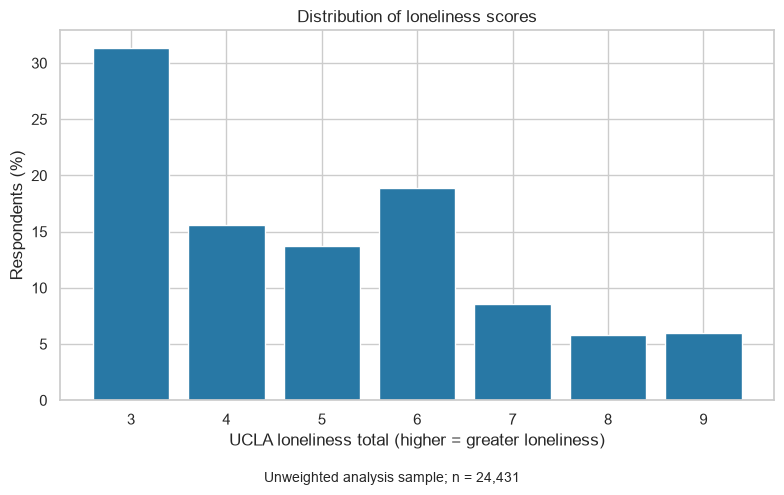

In [ ]:
score_order = list(range(3, 10))
score_counts = df["ucla_total"].value_counts().reindex(score_order, fill_value=0)
loneliness_distribution = pd.DataFrame({
    "ucla_total": score_order,
    "n": score_counts.to_numpy(),
    "percent": 100 * score_counts.to_numpy() / len(df),
})
display(loneliness_distribution.round(2))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(loneliness_distribution["ucla_total"], loneliness_distribution["percent"], color="#2878A5")
ax.set(title="Distribution of loneliness scores",
       xlabel="UCLA loneliness total (higher = greater loneliness)",
       ylabel="Respondents (%)", xticks=score_order)
ax.set_ylim(bottom=0)
fig.text(0.5, 0.02, f"Unweighted analysis sample; n = {len(df):,}", ha="center", fontsize=10)
fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(FIGURES_DIR / "01_loneliness_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
loneliness_distribution.round(2).to_csv(TABLES_DIR / "loneliness_score_distribution.csv", index=False)


The minimum score of 3 is the most common, accounting for approximately 31.3% of the analysis sample. Scores span the full 3–9 range.

## 7 Compare contact-frequency distributions

We use matching axes to compare the face-to-face and remote
contact distributions.

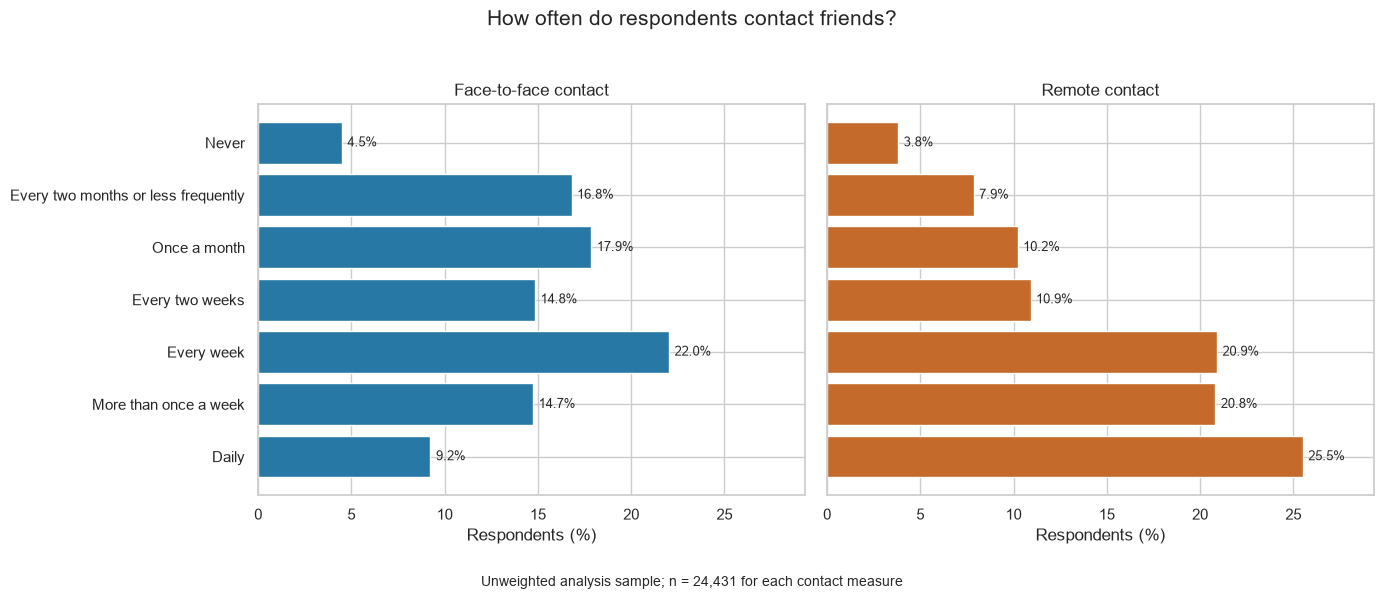

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
max_percent = contact_summary["percent"].max()
for ax, column in zip(axes, contact_cols):
    subset = contact_summary.loc[contact_summary["contact_type"] == contact_names[column]]
    ax.barh(subset["frequency_code"], subset["percent"], color=contact_colours[column])
    ax.set_title(contact_names[column])
    ax.set_xlabel("Respondents (%)")
    ax.set_xlim(0, max_percent * 1.15)
    ax.set_yticks(contact_order)
    ax.set_yticklabels([contact_labels[c].replace("\n", " ") for c in contact_order])
    for row in subset.itertuples(index=False):
        ax.text(row.percent + 0.3, row.frequency_code, f"{row.percent:.1f}%", va="center", fontsize=9)
axes[0].invert_yaxis()
fig.suptitle("How often do respondents contact friends?", fontsize=15)
fig.text(0.5, 0.02, f"Unweighted analysis sample; n = {len(df):,} for each contact measure", ha="center", fontsize=10)
fig.tight_layout(rect=[0, 0.06, 1, 0.95])
fig.savefig(FIGURES_DIR / "02_contact_frequency_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

## 8 Summarise loneliness by contact frequency

We calculate counts, means, medians and variation within each
contact category to support interpretation of the boxplots.

In [9]:
group_tables = []
for column in contact_cols:
    table = (df.groupby(column)["ucla_total"]
        .agg(n="count", mean="mean", sd="std", median="median",
             q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75))
        .reindex(contact_order))
    table.index.name = "frequency_code"
    table = table.reset_index()
    table.insert(0, "contact_type", contact_names[column])
    table["frequency"] = table["frequency_code"].map({c: label.replace("\n", " ") for c, label in contact_labels.items()})
    table["iqr"] = table["q3"] - table["q1"]
    group_tables.append(table)
loneliness_by_contact = pd.concat(group_tables, ignore_index=True)
display(loneliness_by_contact.round(2))
loneliness_by_contact.round(2).to_csv(TABLES_DIR / "loneliness_by_contact_frequency.csv", index=False)

,contact_type,frequency_code,n,mean,sd,median,q1,q3,frequency,iqr
0,Face-to-face contact,1,1096,5.96,2.21,6.0,4.0,8.0,Never,4.0
1,Face-to-face contact,2,4105,5.47,1.96,5.0,4.0,7.0,Every two months or less frequently,3.0
2,Face-to-face contact,3,4364,5.12,1.83,5.0,3.0,6.0,Once a month,3.0
3,Face-to-face contact,4,3627,4.98,1.76,5.0,3.0,6.0,Every two weeks,3.0
4,Face-to-face contact,5,5381,4.70,1.72,4.0,3.0,6.0,Every week,3.0
5,Face-to-face contact,6,3602,4.62,1.68,4.0,3.0,6.0,More than once a week,3.0
6,Face-to-face contact,7,2256,4.71,1.83,4.0,3.0,6.0,Daily,3.0
7,Remote contact,1,930,5.73,2.19,6.0,3.0,8.0,Never,5.0
8,Remote contact,2,1919,5.54,1.97,6.0,4.0,7.0,Every two months or less frequently,3.0
9,Remote contact,3,2496,5.33,1.87,5.0,4.0,6.0,Once a month,2.0


## 9 Compare loneliness across contact categories

The boxplots show medians and quartiles, with diamonds marking
the means. We compare both the overall pattern and the variation
within contact categories.

Responses beyond the whiskers remain valid scores and are not
automatically treated as errors.

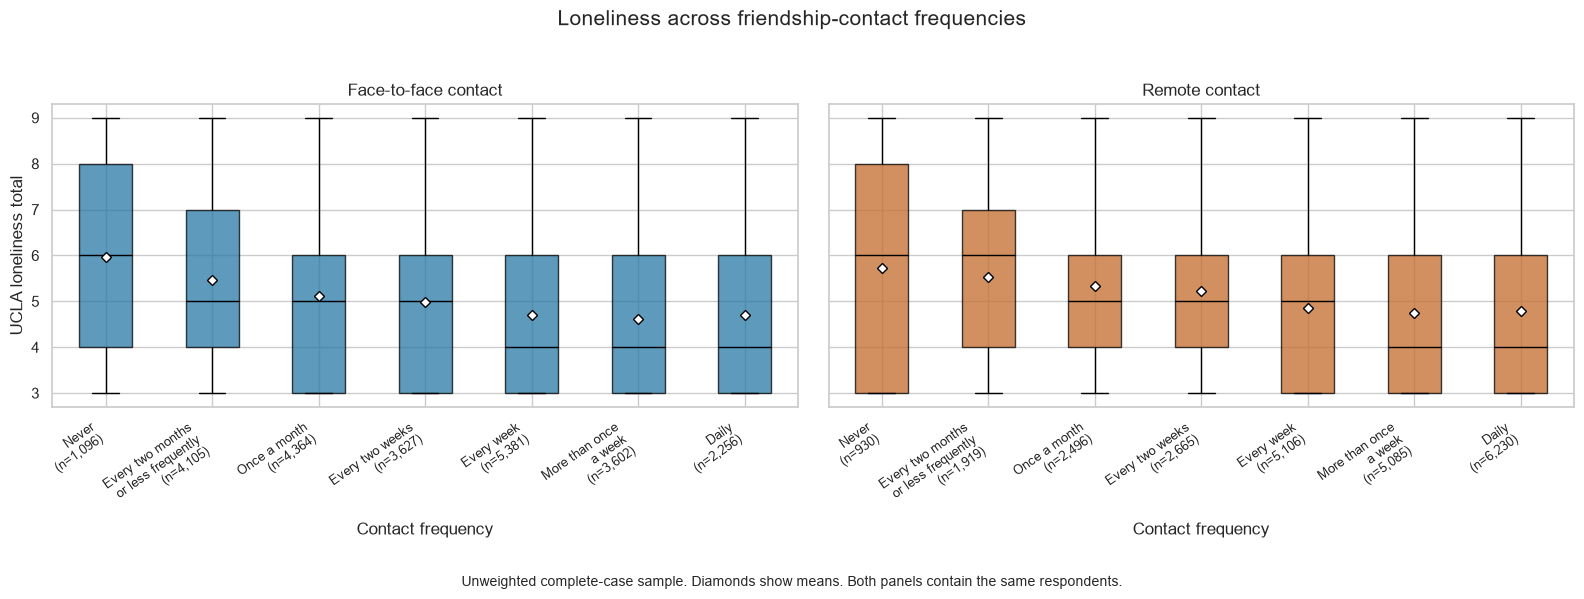

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, column in zip(axes, contact_cols):
    groups = [df.loc[df[column].eq(c), "ucla_total"].to_numpy() for c in contact_order]
    ax.boxplot(groups, positions=list(range(len(contact_order))),
        patch_artist=True, showmeans=True,
        boxprops={"facecolor": contact_colours[column], "alpha": 0.75},
        medianprops={"color": "black"},
        meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 5},
        flierprops={"marker": ".", "markersize": 3, "alpha": 0.3})
    counts = df[column].value_counts().reindex(contact_order, fill_value=0)
    tick_labels = [f"{contact_labels[c]}\n(n={counts.loc[c]:,})" for c in contact_order]
    ax.set_xticks(range(len(contact_order)))
    ax.set_xticklabels(tick_labels, rotation=35, ha="right", fontsize=9)
    ax.set_title(contact_names[column])
    ax.set_xlabel("Contact frequency")
    ax.set_ylim(2.7, 9.3)
    ax.set_yticks(range(3, 10))
axes[0].set_ylabel("UCLA loneliness total")
axes[1].set_ylabel("")
fig.suptitle("Loneliness across friendship-contact frequencies", fontsize=15)
fig.text(0.5, 0.02, "Unweighted complete-case sample. Diamonds show means. Both panels contain the same respondents.", ha="center", fontsize=10)
fig.tight_layout(rect=[0, 0.07, 1, 0.95])
fig.savefig(FIGURES_DIR / "03_loneliness_by_contact_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

## 10 Compare contact–loneliness associations

We use Spearman correlation because contact frequency is ordered
but the category intervals are unequal. It is calculated by
correlating the ranks, with average ranks assigned to tied responses.

The two coefficients describe unadjusted associations in the same
sample. Their comparison does not test whether the difference is
statistically significant.

In [11]:
correlation_cols = contact_cols + ["ucla_total"]
ranked_data = df[correlation_cols].rank(method="average")
spearman_matrix = ranked_data.corr(method="pearson")
correlation_summary = pd.DataFrame({
    "contact_type": [contact_names[c] for c in contact_cols],
    "spearman_rho": [spearman_matrix.loc[c, "ucla_total"] for c in contact_cols],
    "n": len(df),
})
correlation_summary["absolute_rho"] = correlation_summary["spearman_rho"].abs()
display(correlation_summary.round(3))
print("Correlation between the two contact measures:",
      round(spearman_matrix.loc["friends_meet_face", "friends_meet_tele"], 3))
correlation_summary.to_csv(TABLES_DIR / "exploratory_spearman_correlations.csv", index=False)
spearman_matrix.to_csv(TABLES_DIR / "spearman_correlation_matrix.csv")

,contact_type,spearman_rho,n,absolute_rho
0,Face-to-face contact,-0.173,24431,0.173
1,Remote contact,-0.139,24431,0.139


Correlation between the two contact measures: 0.599


## 11 Check contextual data availability

Loneliness may relate to several co-occurring social and personal
circumstances. We therefore also explore demographic characteristics,
social networks, support, health, family contact and participation.

Missing contextual responses do not change the main sample.
Each comparison uses valid responses for the variables involved
and reports its own sample size.

In [12]:
context_variables = {
    "age": "Age",
    "gender_label": "Gender",
    "relationship_label": "Relationship status",
    "work_status_label": "Employment status",
    "education_label": "Education",
    "municipality_type_label": "Area type",
    "health_general_label": "General health",
    "health_condition_label": "Long-term health condition",
    "close_friends_n": "Number of close friends",
    "close_family_n": "Number of close family members",
    "social_support_a": "Practical support",
    "social_support_b": "Emotional support",
    "social_support_c": "Companionship support",
    "social_support_d": "Feeling loved and wanted",
    "family_meet_face": "Face-to-face family contact",
    "family_meet_tele": "Remote family contact",
    "social_activities_a": "Club or association participation",
    "adults_n": "Adults in budget-sharing household",
    "childr_n_0to5": "Children aged 0-5 in household",
    "childr_n_6to15": "Children aged 6-15 in household",
    "others_n": "Other co-residents",
}
needed = set(context_variables) | {"age_group", "close_friends_group", "health_general", "relationship"}
missing_columns = needed - set(df.columns)
if missing_columns:
    raise ValueError(f"Run the UPDATED Notebook 1 first. Missing columns: {sorted(missing_columns)}")

availability = pd.DataFrame({
    "variable": list(context_variables),
    "description": list(context_variables.values()),
    "valid_n": [df[c].notna().sum() for c in context_variables],
    "missing_n": [df[c].isna().sum() for c in context_variables],
})
availability["missing_percent_of_main_sample"] = 100 * availability["missing_n"] / len(df)
display(availability.round(2))
availability.to_csv(TABLES_DIR / "eda_context_availability.csv", index=False)

,variable,description,valid_n,missing_n,missing_percent_of_main_sample
0,age,Age,24431,0,0.00
1,gender_label,Gender,24381,50,0.20
2,relationship_label,Relationship status,24324,107,0.44
3,work_status_label,Employment status,24431,0,0.00
4,education_label,Education,24335,96,0.39
5,municipality_type_label,Area type,24271,160,0.65
6,health_general_label,General health,24296,135,0.55
7,health_condition_label,Long-term health condition,21399,3032,12.41
8,close_friends_n,Number of close friends,22925,1506,6.16
9,close_family_n,Number of close family members,23078,1353,5.54


## 12 Describe the wider sample

We summarise contextual categories and loneliness within those
categories. Missing responses are shown separately in the composition
tables and excluded from category-specific loneliness summaries.

Composition percentages use the full main sample. Nominal categories
are compared as groups rather than treated as numerical ranks.

In [13]:
categorical_context = ["gender_label", "relationship_label", "work_status_label",
    "education_label", "municipality_type_label", "health_general_label",
    "health_condition_label", "age_group", "close_friends_group"]
composition_parts = []
category_parts = []
for column in categorical_context:
    counts = df[column].fillna("Missing / non-response").value_counts()
    composition = counts.rename_axis("category").reset_index(name="n")
    composition.insert(0, "variable", column)
    composition["percent_of_main_sample"] = 100 * composition["n"] / len(df)
    composition_parts.append(composition)

    sub = df.dropna(subset=[column])
    summary = sub.groupby(column)["ucla_total"].agg(n="count", mean="mean", sd="std", median="median").reset_index()
    summary = summary.rename(columns={column: "category"})
    summary.insert(0, "variable", column)
    summary["comparison_valid_n"] = len(sub)
    category_parts.append(summary)

context_composition = pd.concat(composition_parts, ignore_index=True)
context_category_loneliness = pd.concat(category_parts, ignore_index=True)
display(context_composition.round(2))
display(context_category_loneliness.round(2))
context_composition.to_csv(TABLES_DIR / "eda_sample_composition.csv", index=False)
context_category_loneliness.to_csv(TABLES_DIR / "context_category_loneliness.csv", index=False)

count_columns = ["close_friends_n", "close_family_n", "adults_n", "childr_n_0to5", "childr_n_6to15", "others_n"]
count_summary = df[count_columns].describe().T
count_summary["missing_n"] = df[count_columns].isna().sum()
display(count_summary.round(2))
count_summary.to_csv(TABLES_DIR / "context_count_descriptives.csv")

,variable,category,n,percent_of_main_sample
0,gender_label,Female,12645,51.76
1,gender_label,Male,11637,47.63
2,gender_label,In another way,99,0.41
3,gender_label,Missing / non-response,50,0.20
4,relationship_label,Married or cohabitating,13160,53.87
5,relationship_label,Single,5202,21.29
6,relationship_label,In a relationship,3503,14.34
7,relationship_label,Separated or divorced,1803,7.38
8,relationship_label,Widowed,656,2.69
9,relationship_label,Missing / non-response,107,0.44


,variable,category,n,mean,sd,median,comparison_valid_n
0,gender_label,Female,12645,5.13,1.87,5.0,24381
1,gender_label,In another way,99,6.16,1.93,6.0,24381
2,gender_label,Male,11637,4.83,1.81,4.0,24381
3,relationship_label,In a relationship,3503,5.19,1.83,5.0,24324
4,relationship_label,Married or cohabitating,13160,4.70,1.76,4.0,24324
5,relationship_label,Separated or divorced,1803,5.24,1.92,5.0,24324
6,relationship_label,Single,5202,5.52,1.91,6.0,24324
7,relationship_label,Widowed,656,4.87,1.86,4.0,24324
8,work_status_label,"Doing housework, such as looking after childre...",743,5.38,1.96,5.0,24431
9,work_status_label,In education,1463,5.54,1.80,6.0,24431


,count,mean,std,min,25%,50%,75%,max,missing_n
close_friends_n,22925.0,4.14,5.77,0.0,2.0,3.0,5.0,100.0,1506
close_family_n,23078.0,4.67,4.47,0.0,2.0,4.0,6.0,100.0,1353
adults_n,24430.0,2.31,1.60,1.0,2.0,2.0,3.0,30.0,1
childr_n_0to5,24431.0,0.22,0.60,0.0,0.0,0.0,0.0,10.0,0
childr_n_6to15,24430.0,0.44,0.99,0.0,0.0,0.0,1.0,20.0,1
others_n,24431.0,0.44,2.35,0.0,0.0,0.0,0.0,50.0,0


## 13 Explore support, family contact and participation

We examine loneliness across the ordered response categories.
The four support items remain separate rather than being combined
into a new scale.

Higher support codes indicate more available support, while higher
contact and participation codes indicate greater frequency.
Support and loneliness describe related experiences, which matters
when interpreting their associations.

,variable,category_code,n,mean,median,sd,comparison_valid_n,percent_of_valid
0,social_support_a,1.0,2390,5.69,6.0,2.13,21983,10.87
1,social_support_a,2.0,2564,5.79,6.0,1.88,21983,11.66
2,social_support_a,3.0,3877,5.43,6.0,1.75,21983,17.64
3,social_support_a,4.0,6026,4.88,5.0,1.74,21983,27.41
4,social_support_a,5.0,7126,4.33,4.0,1.62,21983,32.42
5,social_support_b,1.0,1746,6.01,6.0,2.17,23587,7.40
6,social_support_b,2.0,3233,5.81,6.0,1.90,23587,13.71
7,social_support_b,3.0,4898,5.35,5.0,1.75,23587,20.77
8,social_support_b,4.0,6349,4.86,5.0,1.73,23587,26.92
9,social_support_b,5.0,7361,4.26,4.0,1.57,23587,31.21


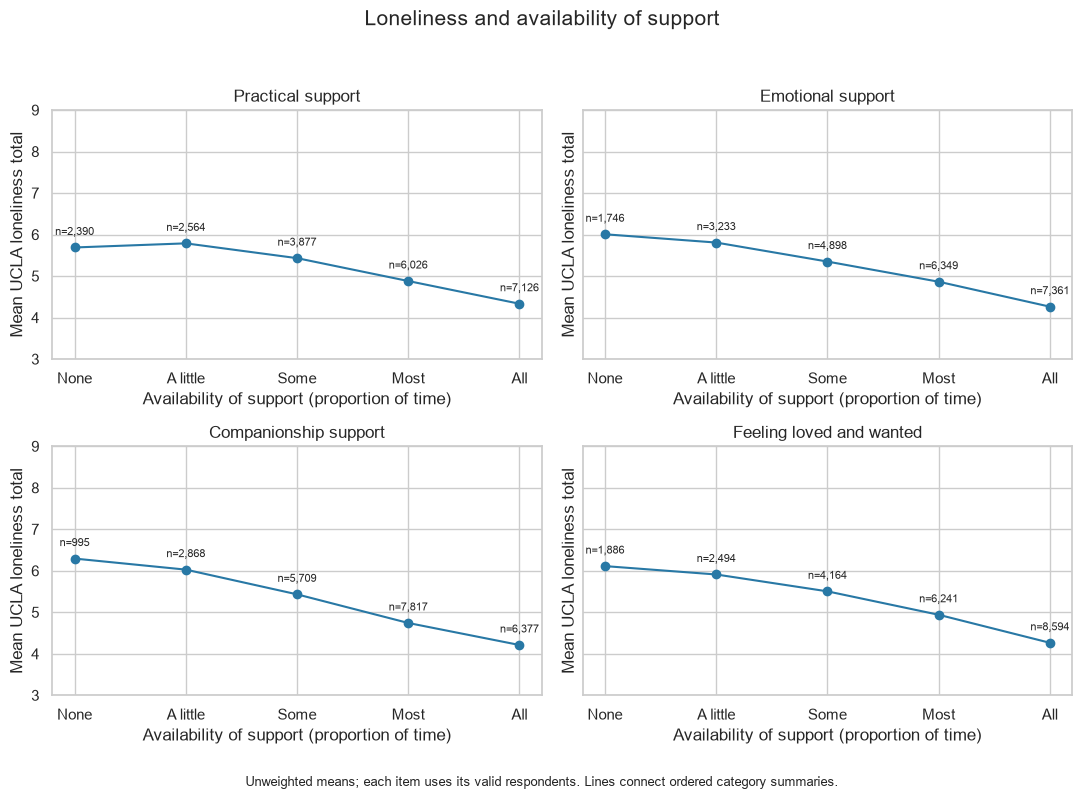

In [14]:
ordered_context = ["social_support_a", "social_support_b", "social_support_c", "social_support_d",
                   "family_meet_face", "family_meet_tele", "social_activities_a"]
ordered_parts = []
for column in ordered_context:
    sub = df.dropna(subset=[column])
    table = sub.groupby(column)["ucla_total"].agg(n="count", mean="mean", median="median", sd="std").reset_index()
    table = table.rename(columns={column: "category_code"})
    table.insert(0, "variable", column)
    table["comparison_valid_n"] = len(sub)
    table["percent_of_valid"] = 100 * table["n"] / len(sub)
    ordered_parts.append(table)
ordered_summary = pd.concat(ordered_parts, ignore_index=True)
display(ordered_summary.round(2))
ordered_summary.to_csv(TABLES_DIR / "ordered_context_loneliness.csv", index=False)

support_labels = ["None", "A little", "Some", "Most", "All"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for ax, column in zip(axes.flat, ordered_context[:4]):
    sub = ordered_summary.loc[ordered_summary["variable"].eq(column)]
    ax.plot(sub["category_code"], sub["mean"], marker="o", color="#2878A5")
    ax.set_title(context_variables[column])
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(support_labels)
    ax.set_ylim(3, 9)
    ax.set_xlabel("Availability of support (proportion of time)")
    ax.set_ylabel("Mean UCLA loneliness total")
    for row in sub.itertuples():
        ax.annotate(f"n={row.n:,}", (row.category_code, row.mean), xytext=(0, 9),
                    textcoords="offset points", ha="center", fontsize=8)
fig.suptitle("Loneliness and availability of support", fontsize=15)
fig.text(0.5, 0.01, "Unweighted means; each item uses its valid respondents. Lines connect ordered category summaries.", ha="center", fontsize=9)
fig.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.savefig(FIGURES_DIR / "04_loneliness_and_support.png", dpi=300, bbox_inches="tight")
plt.show()

## 14 Compare contact patterns within contextual groups

We examine whether the pooled contact–loneliness pattern is also
visible within age, close-friend, support, relationship, health
and family-contact groups.

Both contact panels use the same valid respondents within each
contextual comparison. Points represent category means, and lines
connect them rather than showing fitted regression predictions.

Means based on fewer than 30 respondents are omitted from the plots,
but their counts remain in the exported tables. No uncertainty
intervals are shown.

These comparisons consider one contextual variable at a time
and do not provide simultaneous adjustment.

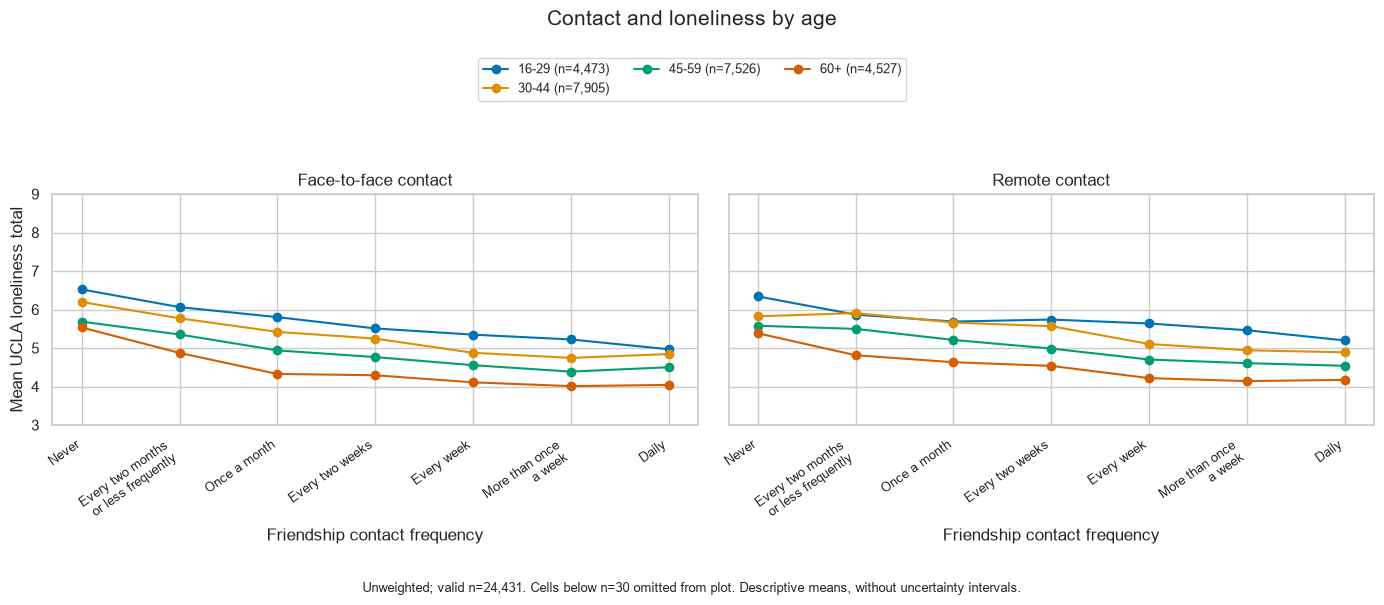

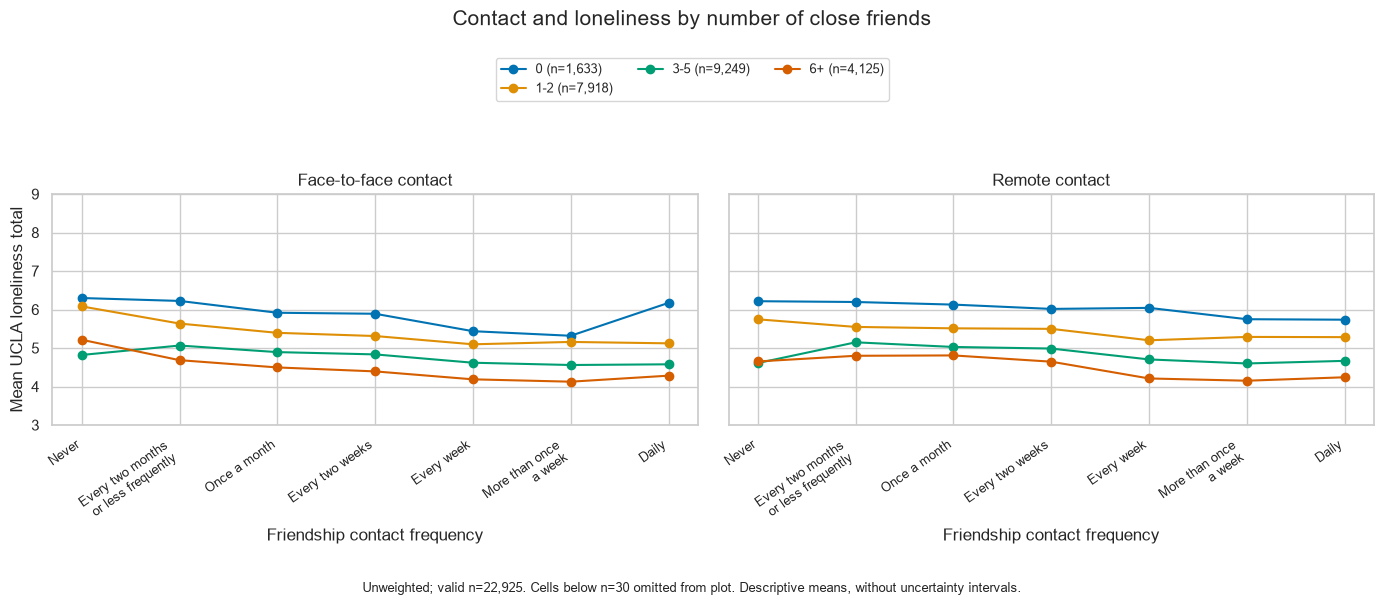

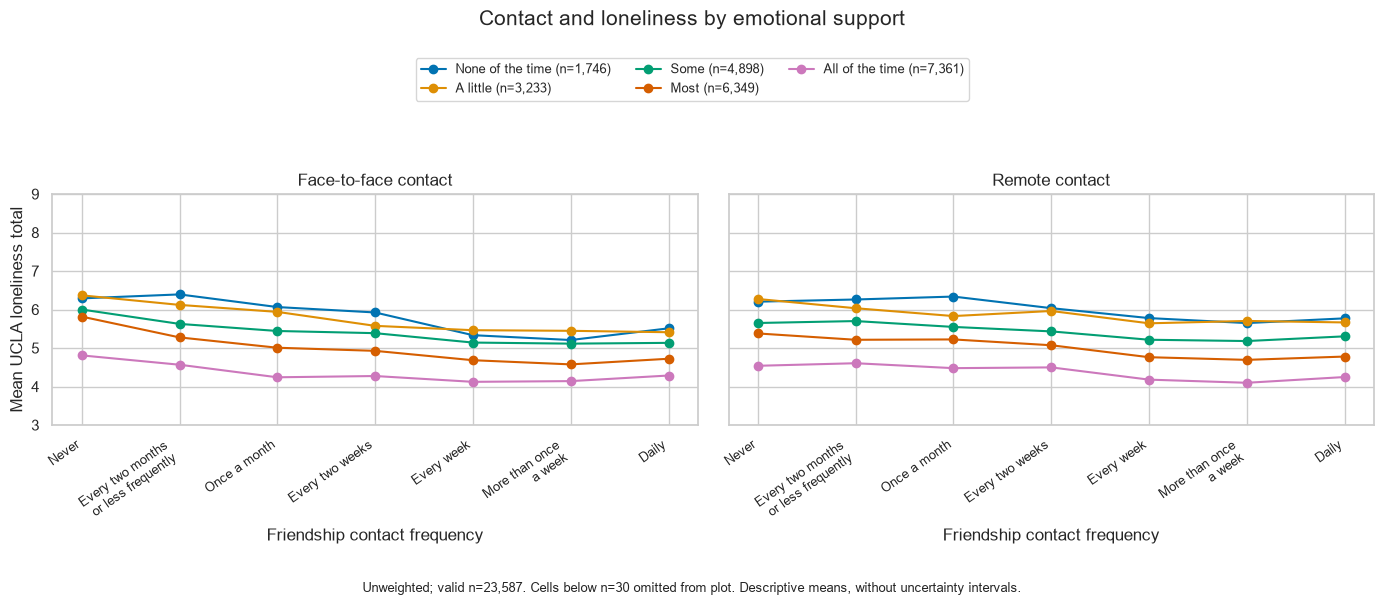

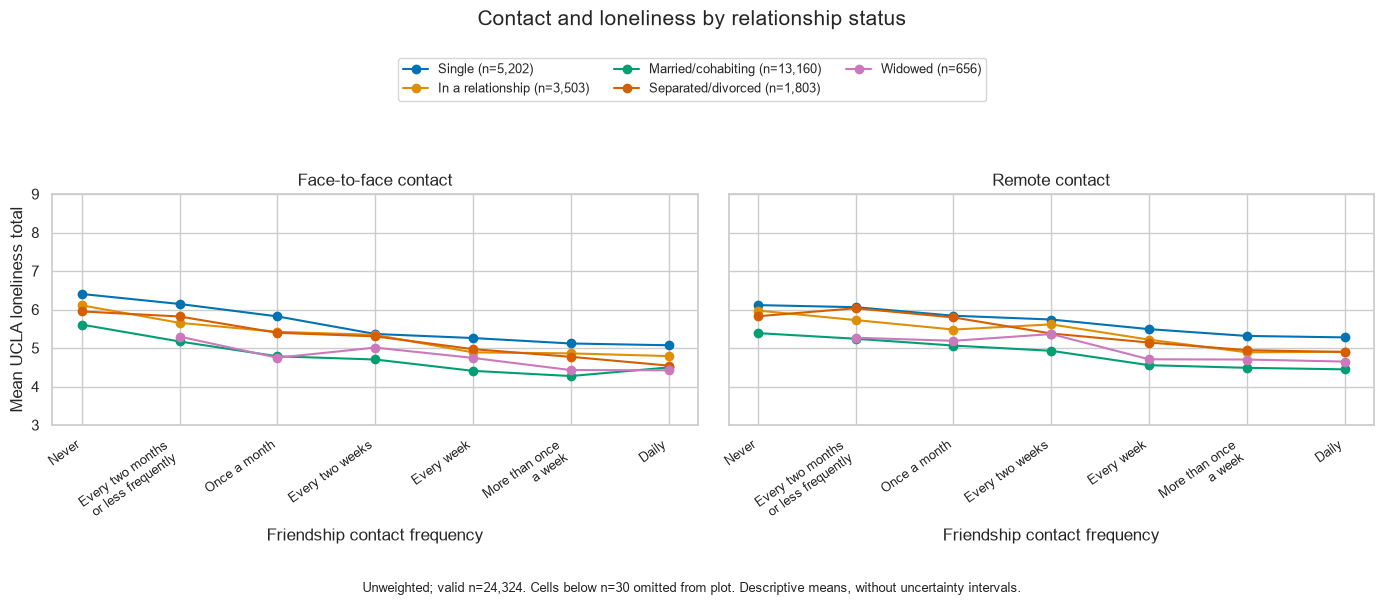

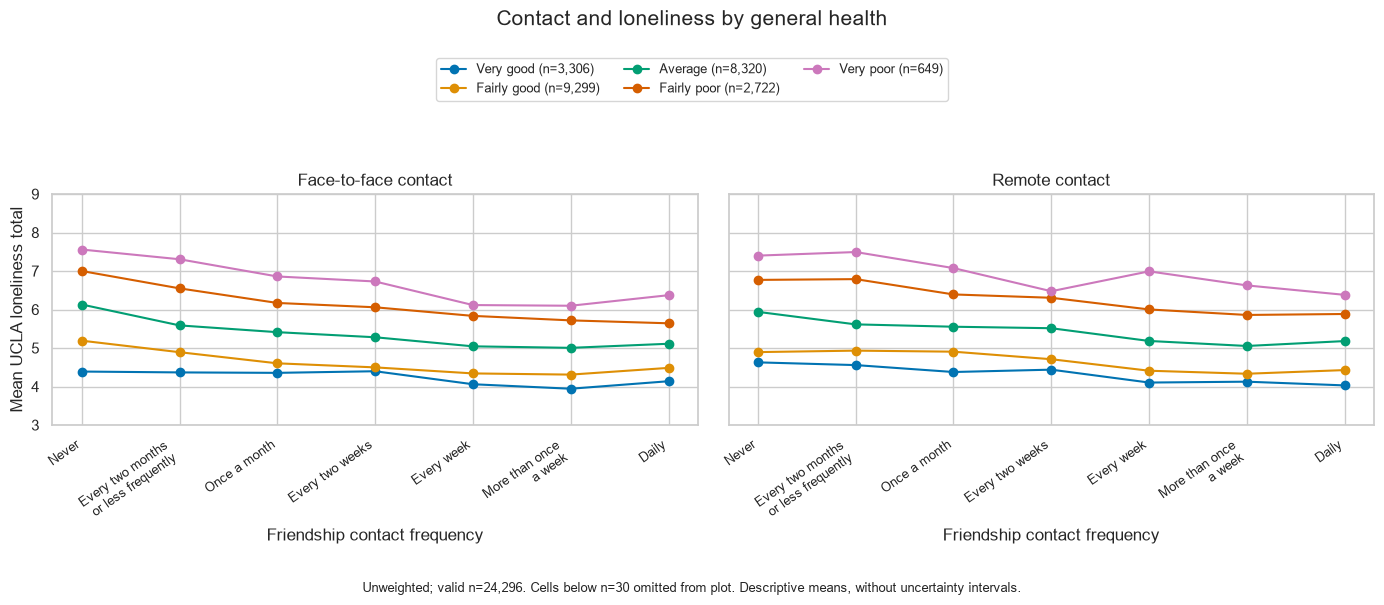

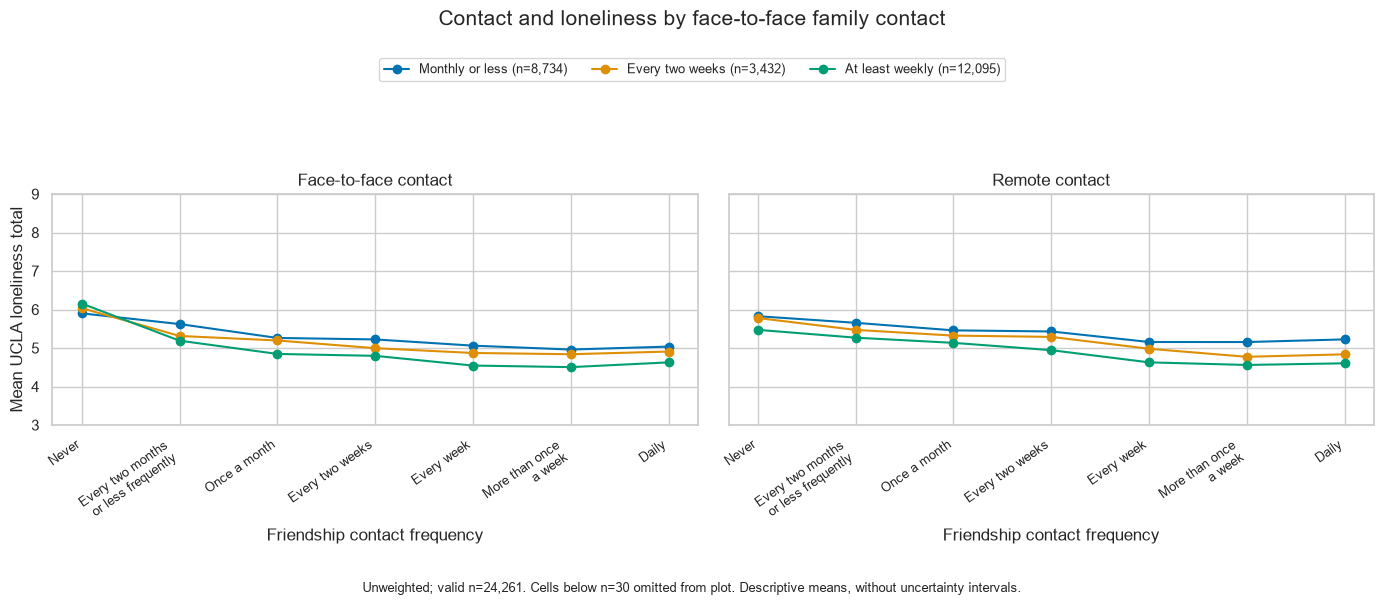

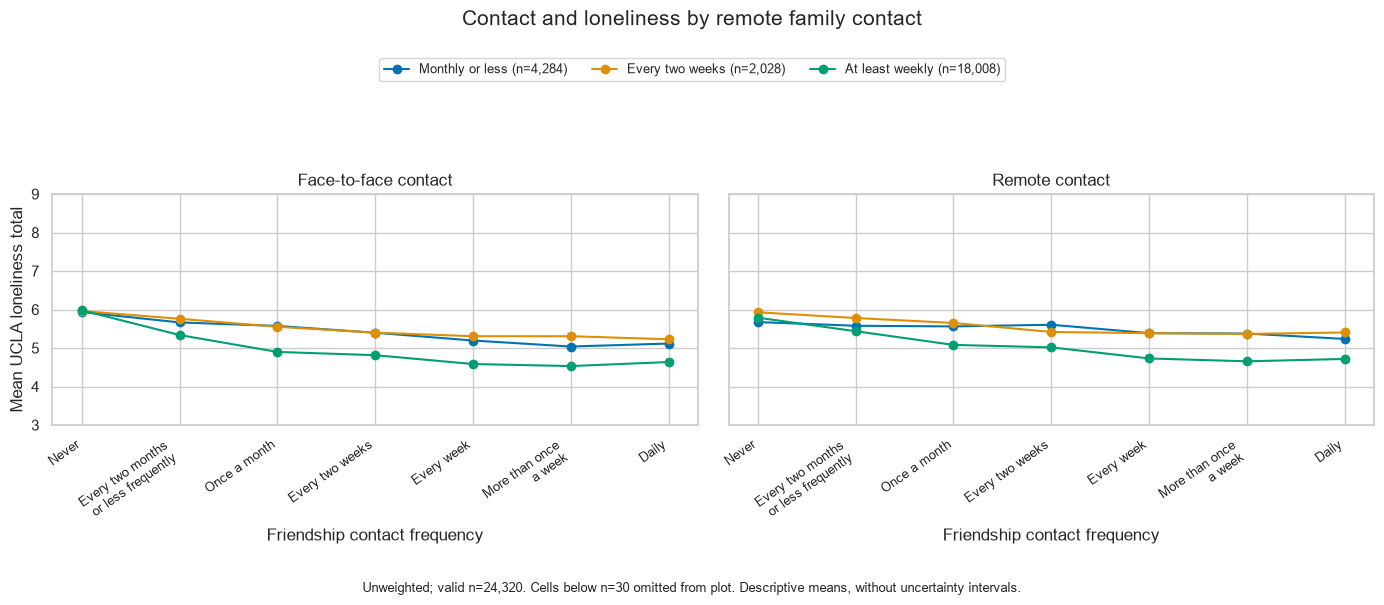

,context_variable,contact_variable,group,contact_frequency_code,n,mean,sd,median,comparison_valid_n,shown_in_plot
0,age_group,friends_meet_face,16-29,1.0,178,6.52,2.03,7.0,24431,True
1,age_group,friends_meet_face,16-29,2.0,530,6.06,1.91,6.0,24431,True
2,age_group,friends_meet_face,16-29,3.0,663,5.80,1.81,6.0,24431,True
3,age_group,friends_meet_face,16-29,4.0,670,5.51,1.75,6.0,24431,True
4,age_group,friends_meet_face,16-29,5.0,915,5.35,1.75,5.0,24431,True
5,age_group,friends_meet_face,16-29,6.0,813,5.22,1.73,5.0,24431,True
6,age_group,friends_meet_face,16-29,7.0,704,4.97,1.81,5.0,24431,True
7,age_group,friends_meet_face,30-44,1.0,354,6.19,2.16,6.0,24431,True
8,age_group,friends_meet_face,30-44,2.0,1298,5.77,1.89,6.0,24431,True
9,age_group,friends_meet_face,30-44,3.0,1500,5.42,1.84,6.0,24431,True


In [16]:
for column in ["family_meet_face", "family_meet_tele"]:
    df[column + "_group"] = pd.cut(df[column], bins=[0, 3, 4, 7],
        labels=["Monthly or less", "Every two weeks", "At least weekly"])

group_specs = {
    "age_group": ("Age", ["16-29", "30-44", "45-59", "60+"], None),
    "close_friends_group": ("Number of close friends", ["0", "1-2", "3-5", "6+"], None),
    "social_support_b": ("Emotional support", [1, 2, 3, 4, 5],
        {1: "None of the time", 2: "A little", 3: "Some", 4: "Most", 5: "All of the time"}),
    "relationship": ("Relationship status", [1, 2, 3, 4, 5],
        {1: "Single", 2: "In a relationship", 3: "Married/cohabiting", 4: "Separated/divorced", 5: "Widowed"}),
    "health_general": ("General health", [1, 2, 3, 4, 5],
        {1: "Very good", 2: "Fairly good", 3: "Average", 4: "Fairly poor", 5: "Very poor"}),
    "family_meet_face_group": ("Face-to-face family contact", ["Monthly or less", "Every two weeks", "At least weekly"], None),
    "family_meet_tele_group": ("Remote family contact", ["Monthly or less", "Every two weeks", "At least weekly"], None),
}

MIN_CELL_N = 30
subgroup_tables = []
for figure_number, (group_col, (group_title, group_order, label_map)) in enumerate(group_specs.items(), start=5):
    sub = df.dropna(subset=[group_col] + contact_cols + ["ucla_total"]).copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    colours = sns.color_palette("colorblind", len(group_order))
    for ax, contact in zip(axes, contact_cols):
        table = sub.groupby([group_col, contact], observed=True)["ucla_total"].agg(n="count", mean="mean", sd="std", median="median").reset_index()
        saved = table.rename(columns={group_col: "group", contact: "contact_frequency_code"})
        saved.insert(0, "context_variable", group_col)
        saved.insert(1, "contact_variable", contact)
        saved["comparison_valid_n"] = len(sub)
        saved["shown_in_plot"] = saved["n"].ge(MIN_CELL_N)
        subgroup_tables.append(saved)
        for group, colour in zip(group_order, colours):
            g = table.loc[table[group_col].eq(group)].set_index(contact).reindex(contact_order)
            group_n = int(sub[group_col].eq(group).sum())
            plotted_mean = g["mean"].where(g["n"].ge(MIN_CELL_N))
            label = label_map[group] if label_map else str(group)
            ax.plot(contact_order, plotted_mean, marker="o", color=colour, label=f"{label} (n={group_n:,})")
        ax.set_title(contact_names[contact])
        ax.set_xticks(contact_order)
        ax.set_xticklabels([contact_labels[c] for c in contact_order], rotation=35, ha="right", fontsize=9)
        ax.set_xlabel("Friendship contact frequency")
        ax.set_ylim(3, 9)
    axes[0].set_ylabel("Mean UCLA loneliness total")
    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 0.91), ncol=3, fontsize=9)
    fig.suptitle(f"Contact and loneliness by {group_title.lower()}", fontsize=15)
    fig.text(0.5, 0.01, f"Unweighted; valid n={len(sub):,}. Cells below n={MIN_CELL_N} omitted from plot. Descriptive means, without uncertainty intervals.", ha="center", fontsize=9)
    fig.tight_layout(rect=[0, 0.06, 1, 0.80])
    fig.savefig(FIGURES_DIR / f"{figure_number:02d}_contact_loneliness_by_{group_col}.png", dpi=300, bbox_inches="tight")
    plt.show()

subgroup_summary = pd.concat(subgroup_tables, ignore_index=True)
display(subgroup_summary.head(20).round(2))
subgroup_summary.to_csv(TABLES_DIR / "contact_loneliness_by_context_groups.csv", index=False)

## 15 Calculate contextual and within-group correlations

We calculate Spearman correlations for relevant numeric and ordered
variables using valid responses for each comparison. Nominal category
codes are excluded.

We also recalculate contact–loneliness correlations within contextual
groups. These can differ because of group composition and restricted
variation.

The coefficients are descriptive. They do not establish independent
effects, statistically significant interactions or predictor importance.

In [17]:
rank_context = ["age", "close_friends_n", "close_family_n", "health_general",
                "social_support_a", "social_support_b", "social_support_c", "social_support_d",
                "family_meet_face", "family_meet_tele", "social_activities_a"]
rank_rows = []
for column in rank_context:
    sub = df[[column, "ucla_total"]].dropna()
    rho = sub.rank(method="average").corr().loc[column, "ucla_total"]
    rank_rows.append({"variable": column, "valid_n": len(sub), "spearman_rho": rho})
context_correlations = pd.DataFrame(rank_rows)
display(context_correlations.round(3))
context_correlations.to_csv(TABLES_DIR / "context_spearman_correlations.csv", index=False)

within_rows = []
for group_col, (title, order, label_map) in group_specs.items():
    for group in order:
        sub = df.loc[df[group_col].eq(group), contact_cols + ["ucla_total"]].dropna()
        for contact in contact_cols:
            rho = float("nan")
            if len(sub) >= MIN_CELL_N and sub[contact].nunique() > 1 and sub["ucla_total"].nunique() > 1:
                rho = sub[[contact, "ucla_total"]].rank(method="average").corr().iloc[0, 1]
            within_rows.append({"context_variable": group_col, "group": group,
                "group_label": label_map[group] if label_map else str(group),
                "contact_variable": contact, "valid_n": len(sub), "spearman_rho": rho})
within_group_correlations = pd.DataFrame(within_rows)
display(within_group_correlations.round(3))
within_group_correlations.to_csv(TABLES_DIR / "within_group_contact_correlations.csv", index=False)

,variable,valid_n,spearman_rho
0,age,24431,-0.219
1,close_friends_n,22925,-0.270
2,close_family_n,23078,-0.234
3,health_general,24296,0.349
4,social_support_a,21983,-0.293
5,social_support_b,23587,-0.324
6,social_support_c,23766,-0.350
7,social_support_d,23379,-0.354
8,family_meet_face,24261,-0.166
9,family_meet_tele,24320,-0.156


,context_variable,group,group_label,contact_variable,valid_n,spearman_rho
0,age_group,16-29,16-29,friends_meet_face,4473,-0.204
1,age_group,16-29,16-29,friends_meet_tele,4473,-0.149
2,age_group,30-44,30-44,friends_meet_face,7905,-0.210
3,age_group,30-44,30-44,friends_meet_tele,7905,-0.184
4,age_group,45-59,45-59,friends_meet_face,7526,-0.187
5,age_group,45-59,45-59,friends_meet_tele,7526,-0.161
6,age_group,60+,60+,friends_meet_face,4527,-0.193
7,age_group,60+,60+,friends_meet_tele,4527,-0.142
8,close_friends_group,0,0,friends_meet_face,1633,-0.113
9,close_friends_group,0,0,friends_meet_tele,1633,-0.073


Within close-friend groups, the contact–loneliness correlations remain
negative but are weaker than in the pooled sample. This motivates
considering network size alongside frequency, but does not show
that it explains away the overall association.

## 16 Validate subgroup outputs

We check that subgroup counts account for the comparison samples,
both contact modes use consistent denominators, and reported means
remain within the 3–9 score range.

In [18]:
for (context, contact), table in subgroup_summary.groupby(["context_variable", "contact_variable"]):
    assert table["comparison_valid_n"].nunique() == 1
    assert table["n"].sum() == table["comparison_valid_n"].iloc[0]
    assert table["mean"].between(3, 9).all()
assert availability["valid_n"].add(availability["missing_n"]).eq(len(df)).all()
print("Contextual checks passed.")
print("Figures saved to:", FIGURES_DIR)
print("Tables saved to:", TABLES_DIR)

Contextual checks passed.
Figures saved to: c:\Users\35383\OneDrive\Documents\GitHub\ProjectCSC1169\results\figures
Tables saved to: c:\Users\35383\OneDrive\Documents\GitHub\ProjectCSC1169\results\tables


## 17 Presentation figures

We export the three selected figures with larger fonts, shorter labels
and simpler annotations for projection. The data and analytical rules
remain unchanged. These versions are saved in
`results/figures/presentation/`.

Saved: c:\Users\ladde\Documents\GitHub\PresentationDraft1\results\figures\presentation\02_contact_frequency_presentation.png


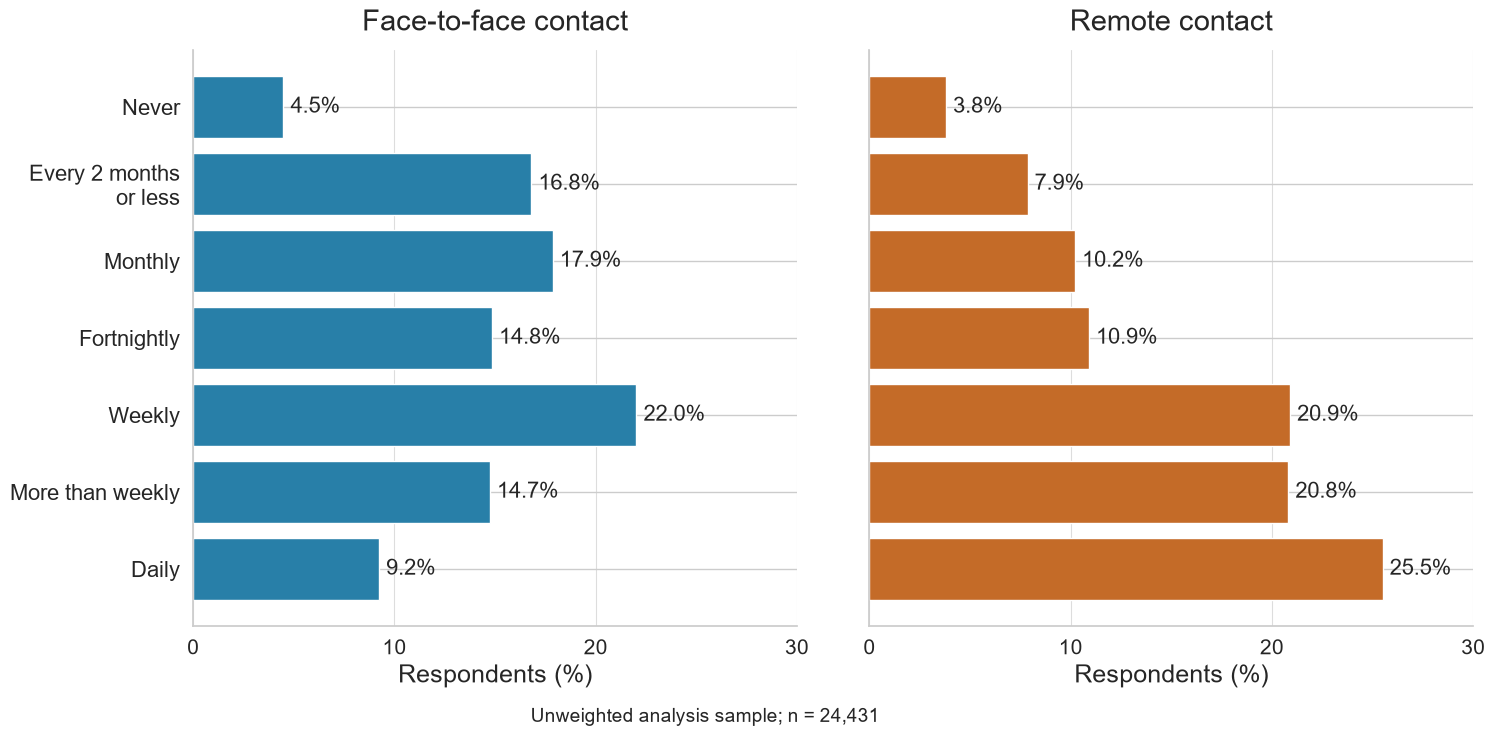

Saved: c:\Users\ladde\Documents\GitHub\PresentationDraft1\results\figures\presentation\03_loneliness_by_contact_presentation.png


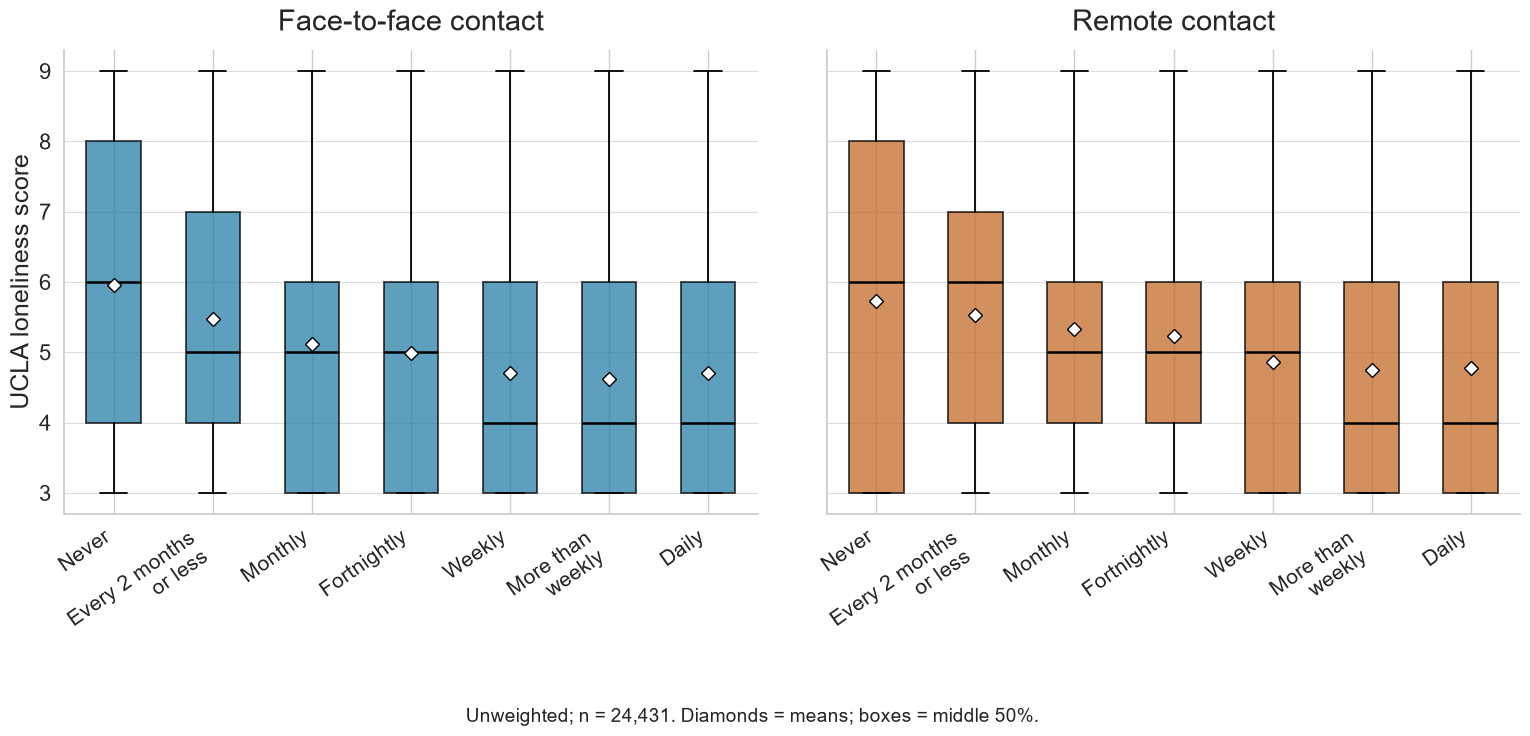

Saved: c:\Users\ladde\Documents\GitHub\PresentationDraft1\results\figures\presentation\06_close_friends_context_presentation.png


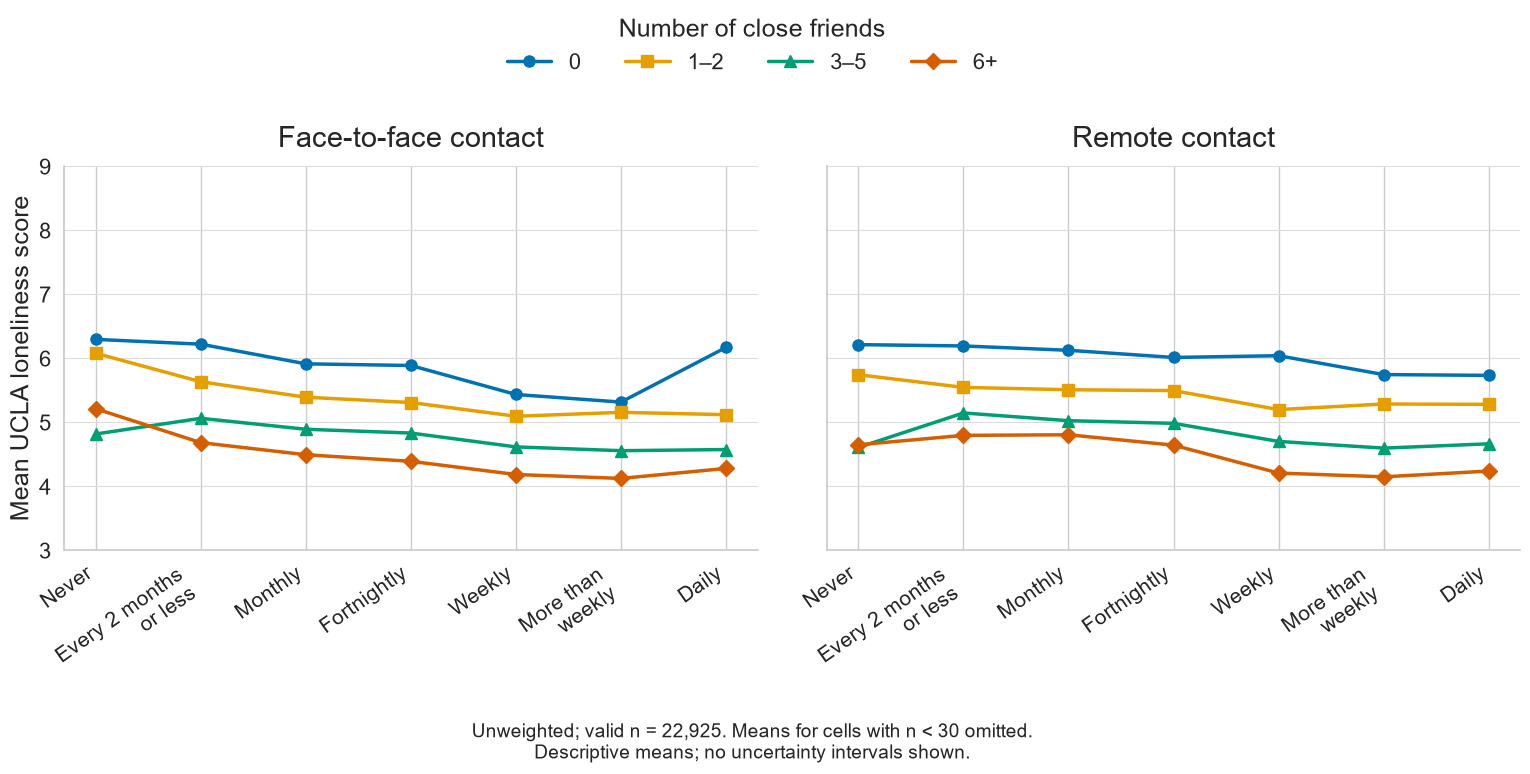

In [17]:
from pathlib import Path
import matplotlib.pyplot as plt

# Save presentation figures separately from the analysis figures.
PRESENTATION_DIR = Path(FIGURES_DIR) / "presentation"
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

contact_columns = ["friends_meet_face", "friends_meet_tele"]
contact_titles = ["Face-to-face contact", "Remote contact"]
contact_colours = ["#287FA8", "#C46B28"]
frequency_codes = list(range(1, 8))

# Shorter labels preserve the original category meanings.
bar_labels = [
    "Never",
    "Every 2 months\nor less",
    "Monthly",
    "Fortnightly",
    "Weekly",
    "More than weekly",
    "Daily",
]

axis_labels = [
    "Never",
    "Every 2 months\nor less",
    "Monthly",
    "Fortnightly",
    "Weekly",
    "More than\nweekly",
    "Daily",
]

# Larger text for projected slides.
presentation_style = {
    "font.size": 16,
    "axes.titlesize": 21,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.spines.top": False,
    "axes.spines.right": False,
}


def format_axis(ax):
    """Use light horizontal gridlines behind the data."""
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)


def save_and_show(fig, filename):
    path = PRESENTATION_DIR / filename
    fig.savefig(path, dpi=300, facecolor="white")
    print(f"Saved: {path}")
    plt.show()
    plt.close(fig)


with plt.rc_context(presentation_style):

    # ---------------------------------------------------------
    # 1. Contact-frequency distributions
    # ---------------------------------------------------------
    fig, axes = plt.subplots(
        1, 2, figsize=(16, 8), sharex=True, sharey=True
    )

    for ax, column, title, colour in zip(
        axes, contact_columns, contact_titles, contact_colours
    ):
        percentages = (
            df[column]
            .value_counts()
            .reindex(frequency_codes, fill_value=0)
            .div(len(df))
            .mul(100)
        )

        ax.barh(frequency_codes, percentages, color=colour)
        ax.set_title(title, pad=14)
        ax.set_xlabel("Respondents (%)")
        ax.set_xlim(0, 30)
        ax.set_xticks([0, 10, 20, 30])
        ax.set_yticks(frequency_codes)
        ax.set_yticklabels(bar_labels)
        ax.set_axisbelow(True)
        ax.grid(axis="x", color="#DDDDDD", linewidth=0.8)

        for code, percentage in percentages.items():
            ax.text(
                percentage + 0.35,
                code,
                f"{percentage:.1f}%",
                va="center",
                fontsize=16,
            )

    axes[0].invert_yaxis()

    fig.subplots_adjust(
        left=0.18, right=0.98, bottom=0.16,
        top=0.88, wspace=0.12
    )
    fig.text(
        0.5, 0.04,
        f"Unweighted analysis sample; n = {len(df):,}",
        ha="center", fontsize=14
    )

    save_and_show(
        fig, "02_contact_frequency_presentation.png"
    )

    # ---------------------------------------------------------
    # 2. Loneliness by contact frequency
    # ---------------------------------------------------------
    fig, axes = plt.subplots(
        1, 2, figsize=(16, 8), sharey=True
    )

    for ax, column, title, colour in zip(
        axes, contact_columns, contact_titles, contact_colours
    ):
        groups = [
            df.loc[df[column].eq(code), "ucla_total"].to_numpy()
            for code in frequency_codes
        ]

        ax.boxplot(
            groups,
            positions=frequency_codes,
            widths=0.55,
            patch_artist=True,
            showmeans=True,
            boxprops={
                "facecolor": colour,
                "alpha": 0.75,
                "linewidth": 1.3,
            },
            medianprops={"color": "black", "linewidth": 1.8},
            whiskerprops={"linewidth": 1.3},
            capprops={"linewidth": 1.3},
            meanprops={
                "marker": "D",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": 7,
            },
            flierprops={
                "marker": ".",
                "markersize": 3,
                "alpha": 0.3,
            },
        )

        ax.set_title(title, pad=14)
        ax.set_xticks(frequency_codes)
        ax.set_xticklabels(
            axis_labels, rotation=35, ha="right"
        )
        ax.set_ylim(2.7, 9.3)
        ax.set_yticks(range(3, 10))
        format_axis(ax)

    axes[0].set_ylabel("UCLA loneliness score")
    fig.subplots_adjust(
        left=0.07, right=0.98, bottom=0.30,
        top=0.88, wspace=0.10
    )
    fig.text(
        0.5, 0.04,
        f"Unweighted; n = {len(df):,}. "
        "Diamonds = means; boxes = middle 50%.",
        ha="center", fontsize=14
    )

    save_and_show(
        fig, "03_loneliness_by_contact_presentation.png"
    )

    # ---------------------------------------------------------
    # 3. Contact and loneliness by close-friend group
    # ---------------------------------------------------------
    friend_groups = ["0", "1-2", "3-5", "6+"]
    friend_labels = ["0", "1–2", "3–5", "6+"]
    group_colours = ["#0072B2", "#E69F00", "#009E73", "#D55E00"]
    group_markers = ["o", "s", "^", "D"]

    sub = df.dropna(
        subset=["close_friends_group", "ucla_total"]
        + contact_columns
    ).copy()

    fig, axes = plt.subplots(
        1, 2, figsize=(16, 8), sharey=True
    )

    for ax, column, title in zip(
        axes, contact_columns, contact_titles
    ):
        summary = (
            sub.groupby(
                ["close_friends_group", column],
                observed=True
            )["ucla_total"]
            .agg(n="count", mean="mean")
            .reset_index()
        )

        for group, label, colour, marker in zip(
            friend_groups, friend_labels,
            group_colours, group_markers
        ):
            values = (
                summary.loc[
                    summary["close_friends_group"].eq(group)
                ]
                .set_index(column)
                .reindex(frequency_codes)
            )

            # Show means only where at least 30 respondents contribute.
            means = values["mean"].where(values["n"].ge(30))

            ax.plot(
                frequency_codes,
                means,
                label=label,
                color=colour,
                marker=marker,
                markersize=8,
                linewidth=2.5,
            )

        ax.set_title(title, pad=14)
        ax.set_xticks(frequency_codes)
        ax.set_xticklabels(
            axis_labels, rotation=35, ha="right"
        )
        ax.set_ylim(3, 9)
        ax.set_yticks(range(3, 10))
        format_axis(ax)

    axes[0].set_ylabel("Mean UCLA loneliness score")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="Number of close friends",
        title_fontsize=18,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=4,
        frameon=False,
    )

    fig.subplots_adjust(
        left=0.07, right=0.98, bottom=0.30,
        top=0.78, wspace=0.10
    )
    fig.text(
        0.5, 0.04,
        f"Unweighted; valid n = {len(sub):,}. "
        "Means for cells with n < 30 omitted.\n"
        "Descriptive means; no uncertainty intervals shown.",
        ha="center", fontsize=14
    )

    save_and_show(
        fig, "06_close_friends_context_presentation.png"
    )

## 18 Summary and limitations

Both face-to-face and remote contact show weak negative associations
with loneliness. The face-to-face association is slightly stronger
descriptively, but the difference has not been formally tested.

Contextual exploration shows that loneliness also varies with
social and personal circumstances. Close-friend groups provide
one example: contact associations remain negative within the groups
but are generally weaker than in the pooled sample.

All results are unweighted and cross-sectional. Self-report,
sample selection and missing responses may influence the findings.
Separate subgroup comparisons do not jointly adjust for other
variables or establish causation.

The next stage is to verify survey-weight definitions and develop
a justified multivariable approach. For predictive modelling,
learned preprocessing will be fitted on training data only.
The current full-sample exploration has already informed our decisions.